<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/03_1_text2cypher_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/08_text2cypher_workshop_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Text2Cypher — Talking to your Knowledge Graph in Plain English

This workshop demo explores **Text2Cypher**: the process of translating a natural-language question into a **Cypher** query that a Large Language Model (LLM) can generate, validate, and execute against a Neo4j knowledge graph.

We will cover:

1. **What is Cypher, and how does it help?**
2. **What is Text2Cypher, and when should you use it?**
3. Text2Cypher with **LangChain + Neo4j** (`GraphCypherQAChain`).


> 📖 Reference: [Neo4j — Text2Cypher Guide](https://neo4j.com/blog/genai/text2cypher-guide/)

## 🗺️ What This Notebook Covers — At a Glance

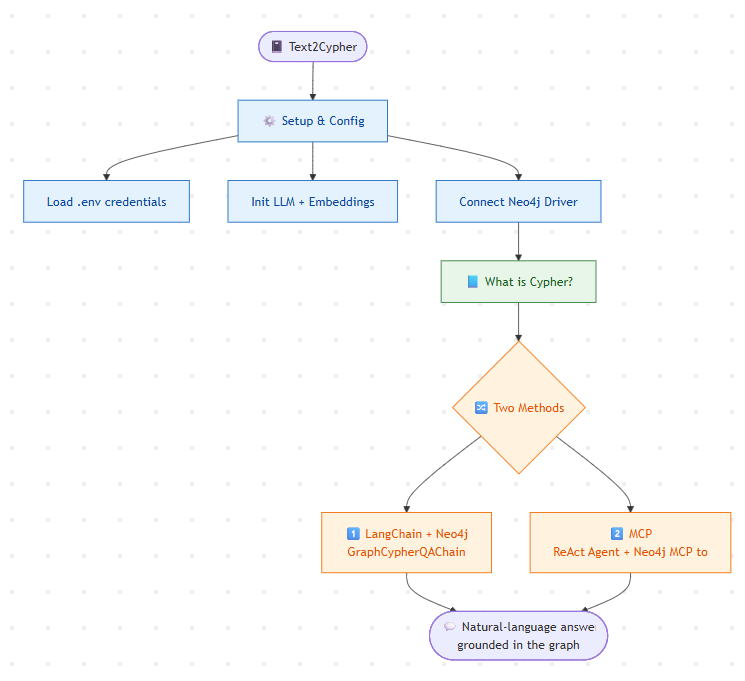

# Setup & Pre-Requisites


In [1]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 382, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 382 (delta 111), reused 57 (delta 55), pack-reused 224 (from 2)
Receiving objects: 100% (382/382), 13.31 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (203/203), done.


## Install Required Packages

In addition to the workshop requirements, we install the LangChain-Neo4j integration and the MCP adapters used in the two methods below.

In [2]:
!pip install -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt --quiet
# !pip install -U --upgrade-strategy eager "mcp>=1.12.0" "langchain-mcp-adapters>=0.1.0" --quiet
!pip install langchain-neo4j langchain-openai langgraph --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.7/263.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.0/358.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.4/669.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━

## Credentials & Drivers
The Neo4j driver allows you to connect and perform read and write transactions with the database.

In [3]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE') or 'neo4j'

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://100.53.52.254
OPENAI key set: True


## Connect to the existing movie graph

In [4]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


## Initialize LLM and Embeddings

We use OpenAI **GPT-5-mini** for generation and **text-embedding-3-small** for embeddings — identical to notebook 03. For the LangChain and MCP methods we use the `langchain-openai` `ChatOpenAI` wrapper so the model plugs into chains and agents.

In [5]:
# neo4j-graphrag primitives (same as notebook 03)
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

llm = OpenAILLM(model_name="gpt-5-mini")
embedder = OpenAIEmbeddings(model="text-embedding-3-small")

# LangChain chat model (used by GraphCypherQAChain and the ReAct agent)
from langchain_openai import ChatOpenAI

chat_llm = ChatOpenAI(model="gpt-5-mini", temperature=0)
print('LLM + embeddings ready ✔')

LLM + embeddings ready ✔


---
# 📘 What is Cypher? And how does it help?

**Cypher** is Neo4j's declarative graph query language — think of it as *“SQL for graphs”*. Instead of joining tables, you describe **patterns** of nodes and relationships using an intuitive, ASCII-art-like syntax:

```cypher
MATCH (p:Person)-[l:LIVES_AT]->(a:Address)
WHERE p.name = "Bob" AND l.since >= date('2025-01-01')
RETURN a.address AS address
```

- `()` → **nodes** (with labels like `:Person`, `:Address`)
- `-[]->` → **relationships** (with types like `:LIVES_AT`, and a direction)
- `WHERE` → **filters** on node/relationship properties
- `RETURN` → the data you want back

### How does it help?
- 🧠 **Expresses relationships naturally** — multi-hop traversals that would need many SQL joins become a single readable pattern.
- ⚡ **Fast graph traversals** — built for connected data (recommendations, fraud rings, knowledge graphs).
- 🔍 **Precise & deterministic** — unlike pure vector search, Cypher answers exact, structured questions (counts, aggregations, filters, shortest paths).

### The challenge 😅
Business users and analysts rarely know Cypher. **Text2Cypher** bridges that gap: an LLM translates a plain-English question into a Cypher query, runs it, and returns a grounded answer.

## The Text2Cypher Workflow

A robust Text2Cypher implementation follows this loop (from the Neo4j guide):

1. The agent **fetches the graph schema** via a tool call.
2. If more information is needed, it iteratively calls other tools until a query can be written.
3. The LLM **generates a Cypher query** using the user question + schema (+ any extra context) as context.
4. The query is **validated** and corrected (by code or LLM).
5. The validated query is **executed** against the database.
6. Any **errors are analysed** and the query is corrected → validated → re-executed (this loop may repeat).
7. On success, the **results feed back** into the context and the agent continues.

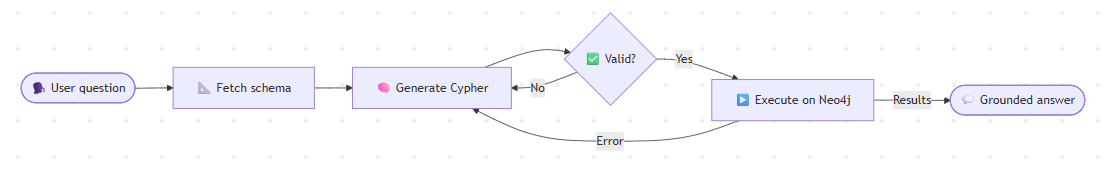

We'll now see **two practical ways** to implement this.

---
# 1️⃣ Method 1 — Text2Cypher with LangChain + Neo4j

The [`langchain-neo4j`](https://docs.langchain.com/oss/python/integrations/graphs/neo4j_cypher) library provides the **`GraphCypherQAChain`** class — a ready-made abstraction for the whole Text2Cypher workflow. It:

- automatically retrieves and formats the **graph schema**,
- prompts the LLM to **generate Cypher**,
- includes a **validation–correction layer** (`CypherQueryCorrector`) that detects reversed relationship directions and fixes them against the schema,
- **executes** the query and passes results to a second LLM call to write the final answer,
- integrates cleanly with the rest of the LangChain / LangGraph ecosystem.

First, we wrap our Neo4j database with the LangChain `Neo4jGraph` object, which exposes the schema to the chain.

In [7]:
from langchain_neo4j import Neo4jGraph
from IPython.display import Markdown

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
    enhanced_schema=True,   # richer schema (property types, example values) improves generation
)

# Refresh + inspect the schema the LLM will use as context
graph.refresh_schema()
Markdown(graph.schema)

Node properties:
- **Movie**
  - `revenue_usd`: INTEGER Min: 2100000, Max: 683241751
  - `runtime_minutes`: INTEGER Min: 109, Max: 190
  - `overview`: STRING Example: "The Eternals are a team of ancient aliens who have"
  - `release_date`: STRING Example: "2021-11-03"
  - `vote_average`: FLOAT Min: 2.88, Max: 8.442
  - `budget_usd`: INTEGER Min: 10000000, Max: 200000000
  - `tagline`: STRING Example: "In the beginning..."
  - `title`: STRING Example: "Eternals"
  - `community`: INTEGER Min: 0, Max: 47
  - `name`: STRING Available options: ['Remo']
- **Person**
  - `name`: STRING Example: "Chloé Zhao"
  - `community`: INTEGER Min: 0, Max: 47
  - `character`: STRING Available options: ['Muthanna', 'Vidya Sinha', 'Shyam']
- **Genre**
  - `name`: STRING Example: "Science Fiction"
  - `community`: INTEGER Min: 0, Max: 47
- **ProductionCompany**
  - `name`: STRING Example: "Marvel Studios"
  - `community`: INTEGER Min: 0, Max: 47
- **Country**
  - `name`: STRING Example: "Canada"
  - `community`: INTEGER Min: 1, Max: 45
- **Language**
  - `name`: STRING Example: "Arabic"
  - `community`: INTEGER Min: 0, Max: 45
- **Keyword**
  - `name`: STRING Example: "superhero"
  - `community`: INTEGER Min: 0, Max: 47
Relationship properties:
- **DIRECTED_BY**
  - `role`: STRING Available options: ['Director', 'director']
  - `details`: STRING Example: "Director"
- **CAST_IN**
  - `details`: STRING Example: "Actor"
  - `role`: STRING Available options: ['actor', 'Bhoomi', 'Actor', 'Arun Sachdeva', 'Dhauli']
  - `character`: STRING Available options: ['Muthanna', 'Wisam Ahmad Kashmiri', 'Shivangi', 'Shyam']
- **HAS_GENRE**
  - `details`: STRING Example: "Genre"
  - `name`: STRING Available options: ['Action', 'Crime']
- **PRODUCED_BY**
  - `details`: STRING Example: "Production company"
  - `name`: STRING Available options: ['Prabhu Deva Studios']
- **PRODUCED_IN**
  - `details`: STRING Example: "Production country"
  - `name`: STRING Available options: ['India']
- **SPOKEN_IN**
  - `details`: STRING Example: "Spoken language"
  - `name`: STRING Available options: ['Tamil']
- **TAGGED_WITH**
  - `details`: STRING Example: "Keyword/tag"
  - `name`: STRING Available options: ['body-swap', 'ancient knowledge']
The relationships:
(:Movie)-[:DIRECTED_BY]->(:Person)
(:Movie)-[:HAS_GENRE]->(:Genre)
(:Movie)-[:PRODUCED_BY]->(:ProductionCompany)
(:Movie)-[:PRODUCED_IN]->(:Country)
(:Movie)-[:SPOKEN_IN]->(:Language)
(:Movie)-[:TAGGED_WITH]->(:Keyword)
(:Person)-[:CAST_IN]->(:Movie)

### Build the `GraphCypherQAChain`

> ⚠️ `allow_dangerous_requests=True` is required because generated Cypher runs directly against the database. In production, connect using a **read-only** Neo4j user so the LLM can never issue write/delete queries.

> Combine graph connector, llm connector and prompt template (below) to create the chain that will handle Text2Cypher process

In [8]:
from langchain_neo4j import GraphCypherQAChain
from langchain_core.prompts.prompt import PromptTemplate

CYPHER_GENERATION_TEMPLATE = """Task:
Generate Cypher statement to query a graph database.

Instructions:
Use only the provided relationship types and properties in the schema.
Do not use any other relationship types or properties that are not provided.

Schema:
{schema}

Note: Do not include any explanations or apologies in your responses.
Do not respond to any questions that might ask anything else than for you to construct a Cypher statement.
Do not include any text except the generated Cypher statement.

Examples: Here are a few examples of generated Cypher statements for particular questions:
# How many people played in Top Gun?
MATCH (m:Movie {{name:"Top Gun"}})<-[:ACTED_IN]-()
RETURN count(*) AS numberOfActors

The question is:
{question}"""

CYPHER_GENERATION_PROMPT = PromptTemplate(
    input_variables=["schema", "question"], template=CYPHER_GENERATION_TEMPLATE
)

chain = GraphCypherQAChain.from_llm(
    llm=chat_llm,
    graph=graph,
    verbose=True,                 # print the generated Cypher + intermediate steps
    cypher_prompt=CYPHER_GENERATION_PROMPT,
    return_intermediate_steps=True,
    allow_dangerous_requests=True,
)
print('GraphCypherQAChain ready ✔')

GraphCypherQAChain ready ✔


### Ask a question in plain English

Watch the `verbose` output: the chain prints the **generated Cypher query**, the **raw results**, and then the **final natural-language answer**.

In [9]:
result = chain.invoke({"query": "List the top 10 highest-rated Hindi movies"})

print("\n=== Generated Cypher ===")
for step in result.get("intermediate_steps", []):
    if "query" in step:
        print(step["query"])

print("\n=== Final Answer ===")
print(result["result"])



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)-[:SPOKEN_IN]->(lang:Language {name: "Hindi"})
RETURN m.title AS title, m.vote_average AS rating
ORDER BY m.vote_average DESC
LIMIT 10
Full Context:
[{'title': 'Spider-Man: Across the Spider-Verse', 'rating': 8.442}, {'title': 'Sonchiriya', 'rating': 8.3}, {'title': 'Lion', 'rating': 8.083}, {'title': 'Jersey', 'rating': 8.0}, {'title': 'Sanam Teri Kasam', 'rating': 7.976}, {'title': 'Dangal', 'rating': 7.934}, {'title': 'Period. End of Sentence.', 'rating': 7.896}, {'title': 'Kammatipaadam', 'rating': 7.8}, {'title': 'Drishyam 2', 'rating': 7.788}, {'title': 'The Farthest', 'rating': 7.707}]

> Finished chain.

=== Generated Cypher ===
MATCH (m:Movie)-[:SPOKEN_IN]->(lang:Language {name: "Hindi"})
RETURN m.title AS title, m.vote_average AS rating
ORDER BY m.vote_average DESC
LIMIT 10

=== Final Answer ===
Spider-Man: Across the Spider-Verse (8.442), Sonchiriya (8.3), Lion (8.083), Jersey (8.0), Sanam Teri Kas

In [10]:
for q in [
    "Which movies did S.S. Rajamouli direct?",
    "How many movies are in the graph?",
    "List down top 5 actors by highest movies",
]:
    display(Markdown(f"\n🗣️  **{q}**"))
    ans = chain.invoke({"query": q})
    print("🤖 ", ans["result"])
    print("====================================================")


🗣️  **Which movies did S.S. Rajamouli direct?**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)-[:DIRECTED_BY]->(p:Person {name:"S.S. Rajamouli"})
RETURN DISTINCT m.title AS movieTitle
Full Context:
[{'movieTitle': 'RRR'}, {'movieTitle': 'Bāhubali 2: The Conclusion'}]

> Finished chain.
🤖  RRR and Bāhubali 2: The Conclusion.



🗣️  **How many movies are in the graph?**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)
RETURN count(m) AS numberOfMovies
Full Context:
[{'numberOfMovies': 496}]

> Finished chain.
🤖  There are 496 movies in the graph.



🗣️  **List down top 5 actors by highest movies**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (p:Person)-[:CAST_IN]->(m:Movie)
RETURN p.name AS actor, COUNT(DISTINCT m) AS movieCount
ORDER BY movieCount DESC
LIMIT 5
Full Context:
[{'actor': 'Prakash Raj', 'movieCount': 21}, {'actor': 'Akshay Kumar', 'movieCount': 19}, {'actor': 'Vijay Sethupathi', 'movieCount': 17}, {'actor': 'Nassar', 'movieCount': 16}, {'actor': 'Fahadh Faasil', 'movieCount': 16}]

> Finished chain.
🤖  Prakash Raj (21), Akshay Kumar (19), Vijay Sethupathi (17), Nassar (16), Fahadh Faasil (16).


✅ **Method 1 takeaways**

- `GraphCypherQAChain` is the fastest way to a working Text2Cypher **proof of concept**.
- It handles schema retrieval, prompting, validation-correction, execution, and answer synthesis for you.
- Best when you want a tight, self-contained chain inside the LangChain ecosystem.

But what if you want the LLM to **decide when** to query the graph, correct its own errors iteratively, and combine graph access with other tools? That's where **MCP + a ReAct agent** shines.

---# 🎯 Wrap-up: LangChain `GraphCypherQAChain` Summary### Key ideas to remember- **Cypher** is how you ask precise, structured questions of a graph — Text2Cypher lets *anyone* do it in plain English.- Always give the LLM a good **schema** (enhanced schema helps a lot).- Add **validation & correction loops** to make generation robust.- Use **read-only** database credentials when the LLM controls the queries.- Text2Cypher works best as an **exploratory or fallback** tool; write dedicated queries for high-frequency, high-complexity questions.📚 **Learn more:** [Neo4j — When and How to Implement Text2Cypher in Agentic Applications](https://neo4j.com/blog/genai/text2cypher-guide/)

In [ ]:
# Clean up the Neo4j driver connection
driver.close()
print('Driver closed. Workshop demo complete 🎉')